In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Lasso Regression – California Housing Price Prediction

**Team 3 | ECS 171 | Zain Muhammad**

This notebook trains and evaluates a Lasso Regression model with L1 regularization to predict California median house values.
The pipeline follows the team's agreed workflow:
- Load the team's feature-selected dataset
- 75 / 25 train-test split
- 5-fold cross-validation for hyperparameter tuning
- Evaluation with RMSE, MAE, and R²
- Feature coefficient analysis and residual visualisation

##1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 120

## 2. Load Data

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ECS 171 - Machine Learning/ProjectEDA/housing_feature_selected.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (20640, 9)


,latitude,housing_median_age,median_income,ocean_proximity_INLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,median_house_value
0,37,41,8,0,1,0,6.984127,0.146591,452600.0
1,37,21,8,0,1,0,6.238137,0.155797,358500.0
2,37,52,7,0,1,0,8.288136,0.129516,352100.0
3,37,52,5,0,1,0,5.817352,0.184458,341300.0
4,37,52,3,0,1,0,6.281853,0.172096,342200.0


## 3. Feature / Target Split and Train-Test Split

In [ ]:
TARGET = 'median_house_value'

X = df.drop(columns=[TARGET])
y = df[TARGET]

print('Features:', list(X.columns))
print(f'X shape: {X.shape}  |  y shape: {y.shape}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)
print(f'Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}')

Features: ['latitude', 'housing_median_age', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN', 'rooms_per_household', 'bedrooms_per_room']
X shape: (20640, 8)  |  y shape: (20640,)
Train size: 15480  |  Test size: 5160


## 4. Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## 5. Baseline Model

In [ ]:
lasso_base = Lasso(random_state=RANDOM_STATE)
lasso_base.fit(X_train_scaled, y_train)

y_pred_base = lasso_base.predict(X_test_scaled)

rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
mae_base  = mean_absolute_error(y_test, y_pred_base)
r2_base   = r2_score(y_test, y_pred_base)

print(f'Baseline RMSE : {rmse_base:,.2f}')
print(f'Baseline MAE  : {mae_base:,.2f}')
print(f'Baseline R2   : {r2_base:.4f}')

Baseline RMSE : 76,513.05
Baseline MAE  : 54,638.96
Baseline R2   : 0.5576


## 6. Hyperparameter Tuning with 5-Fold Cross-Validation

In [ ]:
param_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

lasso = Lasso(max_iter=10000)

grid_search = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print('Best parameters:', grid_search.best_params_)
print(f'Best CV RMSE   : {-grid_search.best_score_:,.2f}')

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters: {'alpha': 0.001}
Best CV RMSE   : 73,290.23


## 7. Evaluate the Tuned Model on the Test Set

In [ ]:
best_lasso = grid_search.best_estimator_

y_pred = best_lasso.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print('Tuned Lasso – Test Set')
print(f'  RMSE : {rmse:,.2f}')
print(f'  MAE  : {mae:,.2f}')
print(f'  R2   : {r2:.4f}')

Tuned Lasso – Test Set
  RMSE : 76,514.06
  MAE  : 54,639.15
  R2   : 0.5576


## 8. Results Summary

In [ ]:
summary = pd.DataFrame({
    'Model' : ['Baseline Lasso (alpha=1.0)', 'Tuned Lasso (alpha=0.001)'],
    'RMSE'  : [round(rmse_base, 2), round(rmse, 2)],
    'MAE'   : [round(mae_base, 2),  round(mae, 2)],
    'R2'    : [round(r2_base, 4),   round(r2, 4)]
})
print(summary.to_string(index=False))

                     Model     RMSE      MAE     R2
Baseline Lasso (alpha=1.0) 76513.05 54638.96 0.5576
 Tuned Lasso (alpha=0.001) 76514.06 54639.15 0.5576


## 9. Visualisations

### 9.1 Feature Coefficients

Features zeroed out by Lasso: 0
                      Feature   Coefficient
2               median_income  80740.652634
3      ocean_proximity_INLAND -32395.495012
7           bedrooms_per_room  17107.412441
1          housing_median_age  11606.833874
6         rooms_per_household   5845.411085
5  ocean_proximity_NEAR OCEAN   5623.423141
0                    latitude   3679.863388
4    ocean_proximity_NEAR BAY   2871.581552


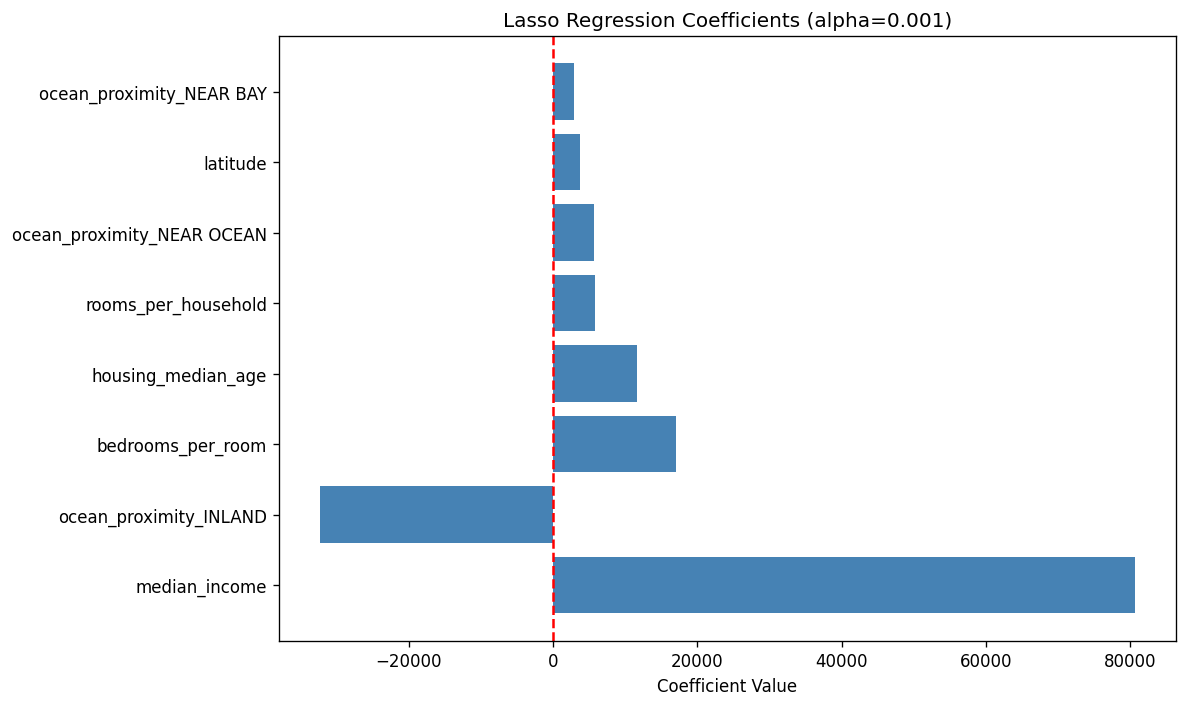

In [ ]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_lasso.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Features zeroed out by Lasso:", (coef_df['Coefficient'] == 0).sum())
print(coef_df)

plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title(f'Lasso Regression Coefficients (alpha={best_lasso.alpha})')
plt.axvline(x=0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

### 9.2 Residual Plot

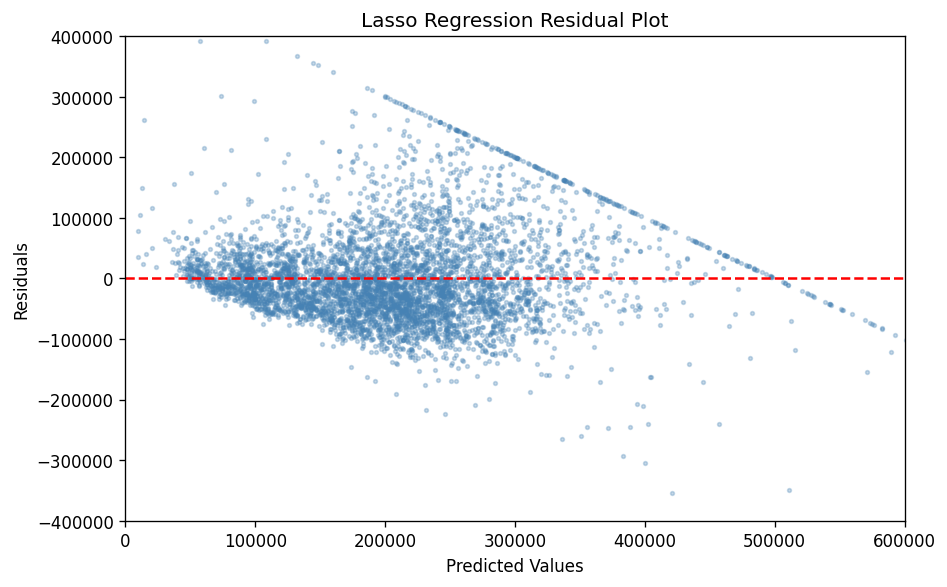

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.3, s=5, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Lasso Regression Residual Plot')
plt.xlim(0, 600000)
plt.ylim(-400000, 400000)
plt.tight_layout()
plt.show()

### 9.3 Predicted vs. Actual Plot

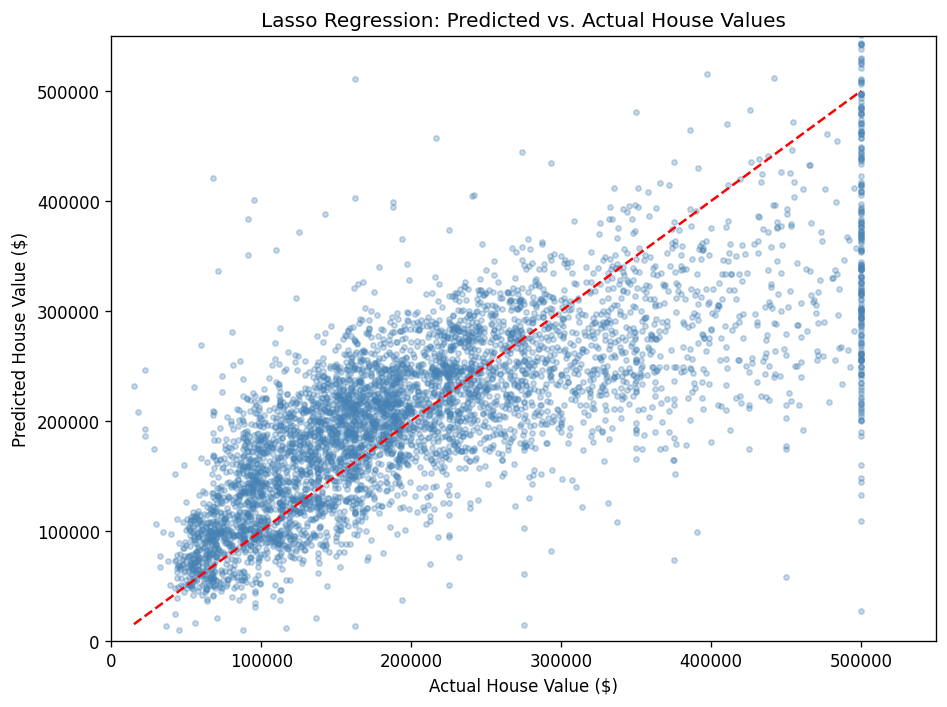

In [25]:
import matplotlib.pyplot as plt

y_pred_train = best_lasso.predict(X_train_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.xlabel('Actual House Value ($)')
plt.ylabel('Predicted House Value ($)')
plt.title('Lasso Regression: Predicted vs. Actual House Values')
plt.xlim(0, 550000)
plt.ylim(0, 550000)
plt.tight_layout()
plt.savefig('lasso_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Model Interpretation

### Performance

The default Lasso model with `alpha=1.0` achieved an RMSE of 76,513 and R² of 0.5576 on the test set. Grid search over 6 alpha values selected `alpha=0.001`, yielding a cross-validated RMSE of 73,290. On the held-out test set the tuned model scored RMSE of $76,514 and R² of 0.5576 — nearly identical to the baseline. The negligible difference between baseline and tuned performance indicates that L1 regularization had minimal impact, likely because the team's prior feature selection had already removed redundant features that Lasso would have otherwise penalized.

### Feature Coefficients

`median_income` has the largest positive coefficient (80,741), confirming it is the strongest predictor of median house value, consistent with findings across all team models. `ocean_proximity_INLAND` has a strong negative coefficient (-32,395), indicating inland properties are associated with significantly lower house values relative to coastal areas. No features were zeroed out by Lasso, confirming that all features retained after the team's feature selection contribute meaningfully to the model.

### Limitations

- **Extrapolation**: As a linear model, Lasso is not bounded by the training data range and can predict values beyond the dataset's $500,001 price cap, producing unrealistic predictions for some samples.
- **Linear assumption**: The downward trend in the residual plot suggests nonlinear relationships in the data that Lasso cannot capture, explaining the lower R² compared to ensemble models used by teammates.
- **R² ceiling**: An R² of 0.56 leaves 44% of variance unexplained, suggesting the linear model is underfitting relative to the ensemble methods used by teammates.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
